## Time Series Analysis (Python)

## 1. SARIMA

In this problem, we consider the monthly data on the unemployment rate in the U.S. measured between January of 1948 and November of 2021. The dataset is saved in the "UNRATENSA.csv" file. More information about the dataset can be found at https://fred.stlouisfed.org/series/UNRATENSA.

We will analyze what 2020 and 2021 would be has there been no COVID-19. We will consider the January 1948 - December 2019 observations only and using ACF/PACF of the time series as well as the analysis of the model residuals, and fit a SARIMA type model we find most suitable.

We will plot January 2015 - December 2019 observations of the unemployment rate with fitted values, i.e. one month ahead predictions obtained with the model trained on the January 2015 - December 2019 observations. Subsequently, we'll add the forecast for Jan 2020 – Nov 2021 (based on Jan 1948 - Dec 2019 only as input) along with the 95% prediction intervals to the same plot. Finally, we'll add the actual realization of the 2020 and 2021 unemployment rate. bold text


SOLUTION

In [ ]:
# ! pip install arch
# !pip install statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.api as smt
from sklearn.metrics import mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model


from pandas import DataFrame
from pandas import concat
import itertools
from itertools import product
from tqdm import tqdm_notebook

import keras
from keras import layers
from keras import models
from keras import optimizers
from keras import regularizers
from keras.regularizers import l2
from keras.layers import LSTM
from keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping


import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('UNRATENSA.csv',parse_dates=True,index_col='DATE')
xt = df[['UNRATENSA']]
print('Number of missing values: ',xt.isnull().values.sum())
print('Number of observations: ', xt.shape[0])
xt.head()

Number of missing values:  0
Number of observations:  887


,UNRATENSA
DATE,
1948-01-01,4.0
1948-02-01,4.7
1948-03-01,4.5
1948-04-01,4.0
1948-05-01,3.4


In [ ]:
# setting aside January 1948 - December 2019 observations  as training set
xt_train = xt.iloc[:72*12]
xt_test = xt.iloc[72*12:]

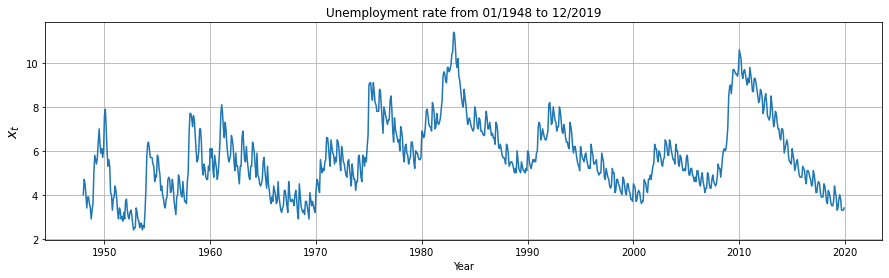

In [ ]:
# plot time series
plt.figure(figsize=(15,4))
plt.plot(xt_train)
plt.ylabel("$x_t$",fontsize=14)
plt.xlabel("Year")
plt.title("Unemployment rate from 01/1948 to 12/2019")
plt.grid(True)

The time series does not appear to be stationary. We see that we have some sort of trend on some of the periods and seasonality.  
Let's plot PACF and ACF to confirm.

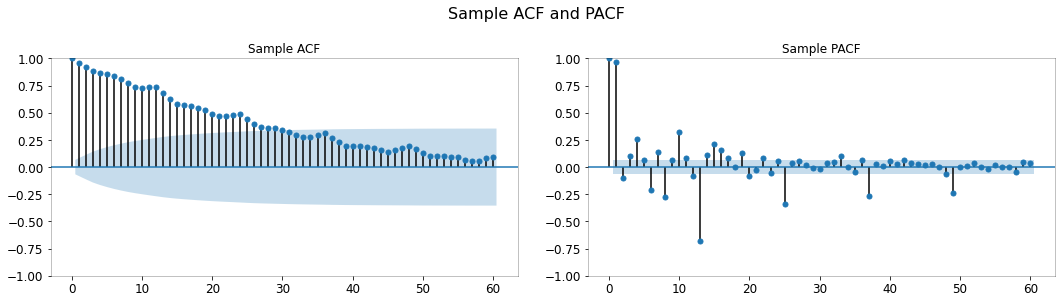

In [ ]:
h_max = 60
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, figsize=(18,4))
fig.suptitle('Sample ACF and PACF',y=1.06,size=16)
plt.subplots_adjust(wspace = 0.15)
plot_acf(xt_train, ax=ax[0], lags=h_max)
plot_pacf(xt_train, ax=ax[1], lags=h_max)

for k in range(2):
    ax[k].tick_params(axis='both', labelsize=12)
    [ax[k].spines[line].set_alpha(.3) for line in ["top","bottom","right","left"]]

ax[0].set_title("Sample ACF")
ax[1].set_title("Sample PACF")

plt.show()

From the ACF plot we can see that we have a trend. There is no cut-off at the ACF plot, and the values are gradualy decaying.    
The PACF plot confirms that we have a seasonal component with $s=12$. As we see significan spikes at lags $h=1,13,25,37,49$.

We will take a 1st order difference to see if we can make a removement.

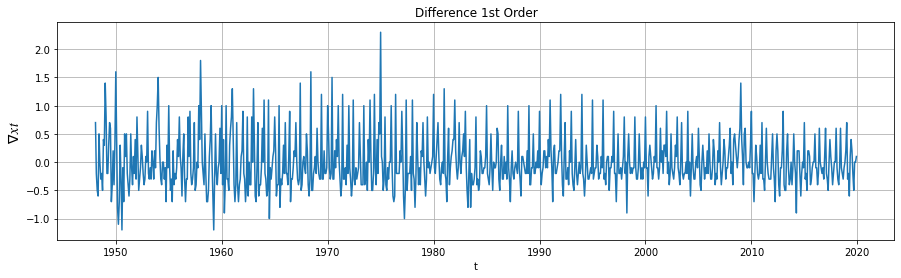

In [ ]:
# Difference 1st Order
plt.figure(figsize=(15,4))
plt.plot(xt_train.diff())
plt.title('Difference 1st Order')
plt.ylabel("$∇𝑥𝑡$ ",fontsize=14)
plt.xlabel("t")
plt.grid(True)

We were able to remove the trend. Now the time series appears stationary and has mean centered around zero.

In [ ]:
# drop 1 row with NaN value caused by the difference
xt_diff1 = xt_train.diff(1)
print('Number of missing values in ∇𝑥𝑡 before dropping NaN: ',xt_diff1.isnull().values.sum())
xt_diff1 = xt_diff1.dropna()
print('Number of missing values in ∇𝑥𝑡 after dropping NaN: ',xt_diff1.isnull().values.sum())
print('Number of observations in ∇𝑥𝑡: ', xt_diff1.shape[0])

Number of missing values in ∇𝑥𝑡 before dropping NaN:  1
Number of missing values in ∇𝑥𝑡 after dropping NaN:  0
Number of observations in ∇𝑥𝑡:  863


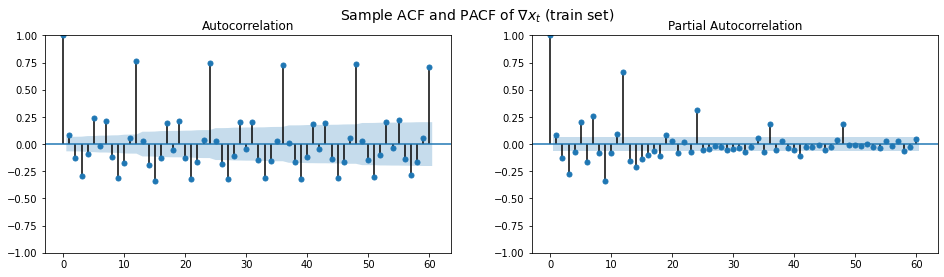

In [ ]:
# ACF and PACF
h_max = 60
fig, axes = plt.subplots(1,2,figsize=(16,4))
fig.suptitle('Sample ACF and PACF of ∇$x_t$ (train set)',size=14)
plot_acf(xt_diff1, lags=h_max, ax=axes[0])
plot_pacf(xt_diff1, lags=h_max, method='ywm', ax=axes[1])
plt.show()

From the PACF we can see that there is a seasonal component with $s=12$. Also, if we look at lags $h=12,24,36,48$ only, then the PACF plot we can conclude that the seasonal component is AR(P) of "fourth" order. There is no seasonal cut-off at the ACF plot. $P=4$ and $Q=0$ for seasonal component SARIMA model would be a reasonable starting point.

If we now look at lags $h=0,1,\ldots,10$ only, from both ACF and PACF we can see that there is no a clear cut-off at neither.   
We will try a few reasonable values and analyze the residuals.

In [ ]:
# estimating parameters of SARIMA(p,1,q)x(P,1,Q)12, p=1,2,3,4
p = [0,1,1,1,1,1,2,2,2,3,2,3,3]
q = [1,0,1,2,2,2,1,2,3,2,0,0,0]
P = [1,1,1,0,0,0,0,0,2,2,2,3,4]
Q = [0,0,0,1,2,3,1,1,0,2,0,0,0]
res = [SARIMAX(xt_train,trend=None,order=(p[case],1,q[case]),seasonal_order=(P[case], 1, Q[case], 12),\
               enforce_stationarity=False).fit().resid for case in range(len(p))]

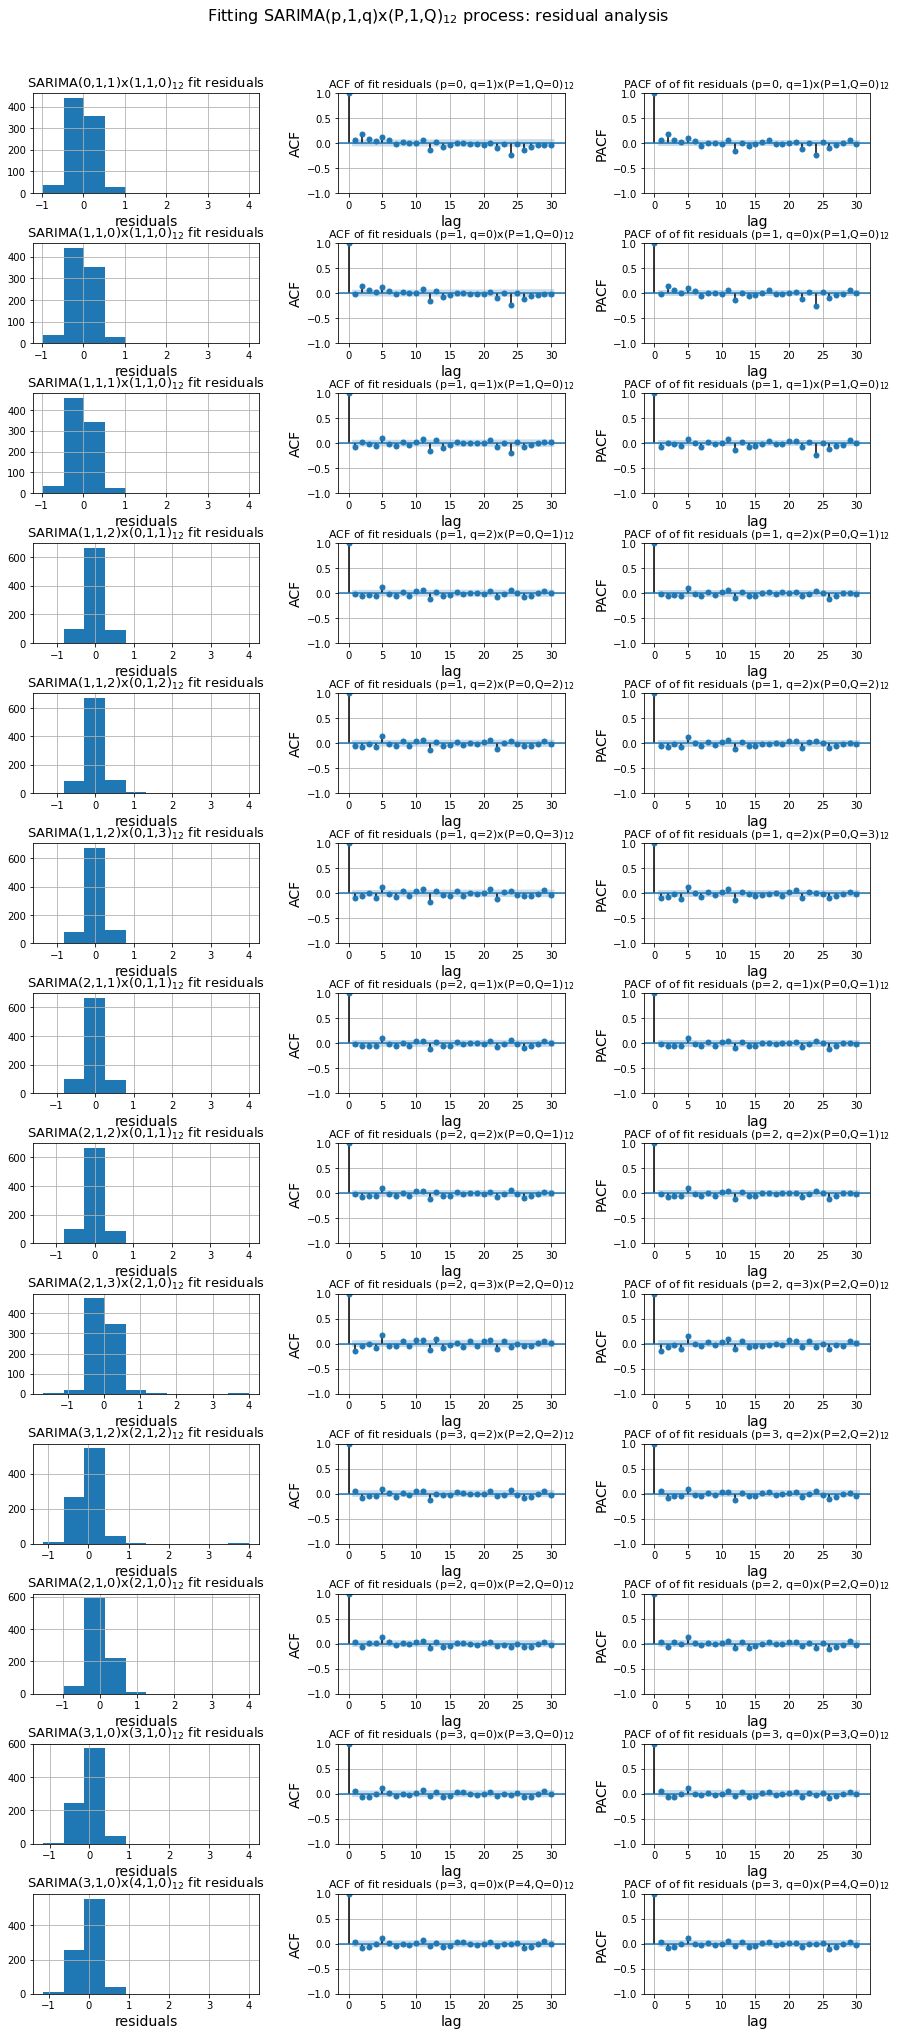

In [ ]:
h_max = 30

fig, ax = plt.subplots(nrows=len(p), ncols=3, sharex=False, figsize=(15,30))
fig.suptitle("Fitting SARIMA(p,1,q)x(P,1,Q)$_{12}$ process: residual analysis", y=0.92,size=16)
plt.subplots_adjust(wspace = 0.35,hspace = 0.5,bottom = 0)

for case in range(len(p)):
    ax[case][0].hist(res[case])
    ax[case][0].set_xlabel("residuals",fontsize=14)
    ax[case][0].set_title("SARIMA("+str(p[case])+",1,"+str(q[case])+")x("+str(P[case])+",1,"+str(Q[case])+")$_{12}$ fit residuals",fontsize=13)
    ax[case][0].grid(True)

    plot_acf(res[case], ax=ax[case][1], lags=h_max)
    ax[case][1].set_xlabel("lag",fontsize=14)
    ax[case][1].set_ylabel("ACF",fontsize=14)
    ax[case][1].set_title("ACF of fit residuals (p="+str(p[case])+", q="+str(q[case])+")x(P="+str(P[case])+",Q="+str(Q[case])+")$_{12}$",fontsize=11)
    ax[case][1].grid(True)

    plot_pacf(res[case], ax=ax[case][2], lags=h_max)
    ax[case][2].set_xlabel("lag",fontsize=14)
    ax[case][2].set_ylabel("PACF",fontsize=14)
    ax[case][2].set_title("PACF of of fit residuals (p="+str(p[case])+", q="+str(q[case])+")x(P="+str(P[case])+",Q="+str(Q[case])+")$_{12}$",fontsize=11)
    ax[case][2].grid(True)

We see that SARIMA $(3,1,0)$x$(4,1,0)_{12}$ can be a good fit. The histogram plot looks a bit skewed though. Let's fit the model and check the diagnostics plots.

Additionally, a few combination of values of 1 and 2 in AR and MA components look promising as well.

In [ ]:
model = SARIMAX(xt_train,
                trend=None,
                order=(3,1,0),
                seasonal_order=(4, 1, 0, 12))
model_fit = model.fit()
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  864
Model:             SARIMAX(3, 1, 0)x(4, 1, 0, 12)   Log Likelihood                  20.119
Date:                            Fri, 17 Dec 2021   AIC                            -24.238
Time:                                    00:58:50   BIC                             13.733
Sample:                                01-01-1948   HQIC                            -9.694
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1183      0.029      4.077      0.000       0.061       0.175
ar.L2          0.2034      0.031   

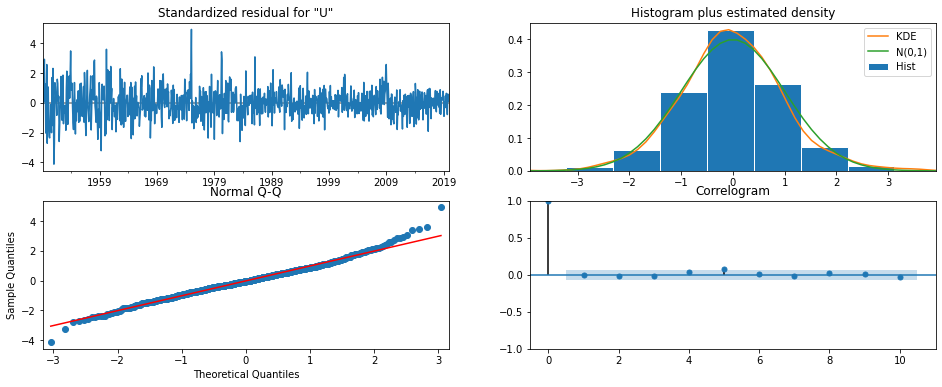

In [ ]:
model_fit.plot_diagnostics(figsize=(16, 6))
plt.show()

From Q-Q plot and histogram, we see that the distribution is nearly normal. Additionally, from correlogram, we see that there is no correlation between residuals. One value at the lag=5 is somewhat on the edge of the rejection interval.   

The currenct model's AIC = - 24.24. We check a few other options to evaluate if we can optimize the model by reducing AIC at the same time possibly reducing the number of parameters and still satisfying the diagnostic plots' requirements.

In [ ]:
def _get_best_model(tms):
    best_aic = np.inf
    best_order = None
    best_mdl = None

    pq_rng = range(3)
    d_rng = range(2)
    for i in pq_rng:
      for d in d_rng:
        for j in pq_rng:
          for k in pq_rng:
            for v in pq_rng:
              tmp_mdl = SARIMAX(tms,trend=None,order=(i,d,j),seasonal_order=(k, d, v, 12)).fit()
              tmp_aic = tmp_mdl.aic
              if tmp_aic < best_aic:
                best_aic = tmp_aic
                best_order = (i, d, j, k, v)
                best_mdl = tmp_mdl

    print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))
    return best_aic, best_order, best_mdl

res_tup = _get_best_model(xt_train)

aic: -53.99520 | order: (2, 1, 1, 0, 1)


As we observed earlier that SARIMA $(2,1,1)$x$(0,1,1)_{12}$ can be a good fit, it is actually gives us almost as twice smaller AIC and has fewer parameters.   

Let's fit it and check the residuals.

In [ ]:
model_sar2 = SARIMAX(xt_train,
                trend=None,
                order=(2,1,1),
                seasonal_order=(0, 1, 1, 12))
model_fit_sar2 = model_sar2.fit()
print(model_fit_sar2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          UNRATENSA   No. Observations:                  864
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                  31.998
Date:                            Fri, 17 Dec 2021   AIC                            -53.995
Time:                                    01:03:45   BIC                            -30.263
Sample:                                01-01-1948   HQIC                           -44.905
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5861      0.095      6.189      0.000       0.400       0.772
ar.L2          0.1367      0.041   

We also see that we have a smaller BIC measure and larger Log Likelihood. Additionally, all coefficients are statistically significant.

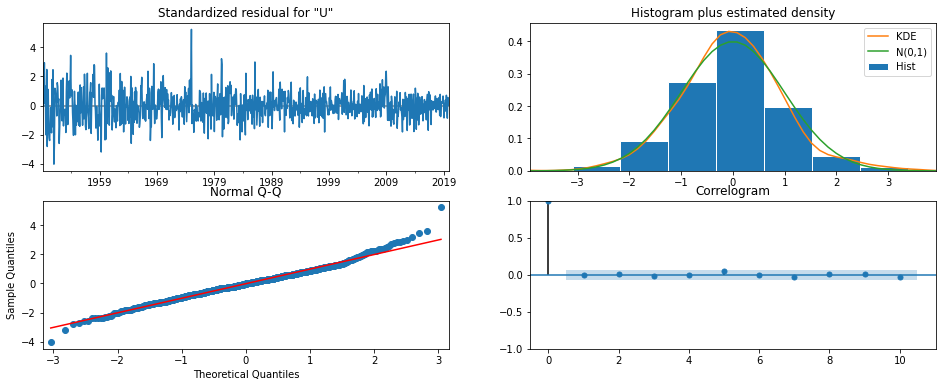

In [ ]:
model_fit_sar2.plot_diagnostics(figsize=(16, 6))
plt.show()

From Q-Q plot and histogram, we see that the distribution is nearly normal. Additionally, from correlogram, we see that there is no correlation between residuals.  

We will select it as our best SARIMA model.

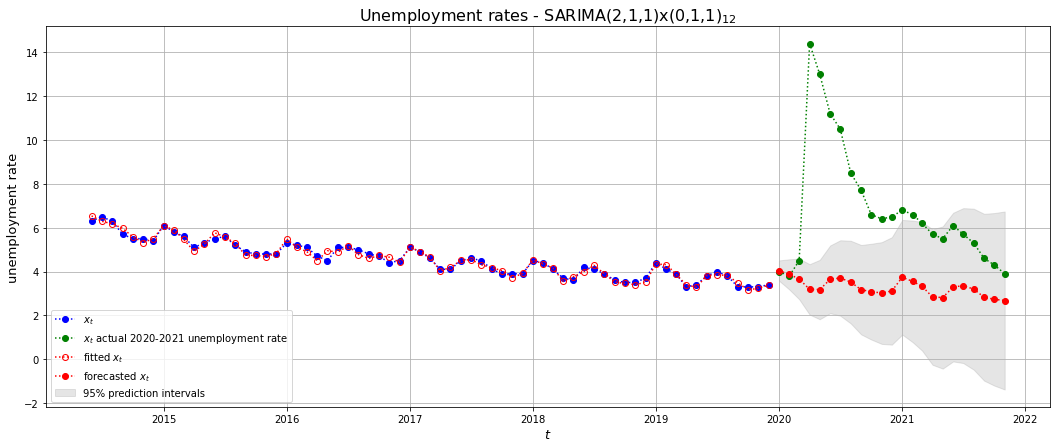

In [ ]:
# Forecasting
xt_fitted = model_fit.predict()
plt.figure(figsize=(18,7))
plt.plot(xt_train.index[-67:],xt_train.iloc[-67:],linestyle=':', marker='o',color='blue',label = "$x_t$")
plt.plot(xt_test.index,xt_test,linestyle=':', marker='o',color='green',label = "$x_t$ actual 2020-2021 unemployment rate")
plt.plot(xt_train.index[-67:],xt_fitted.iloc[-67:],linestyle=':', marker='o', mfc='none', color='red',label = "fitted $x_t$")
plt.title("Unemployment rates - SARIMA(2,1,1)x(0,1,1)$_{12}$", fontsize=16)

# forecast m steps ahead starting from n+1
m=23
forecast_results = model_fit.get_forecast(steps=m)
xt_forecasted = forecast_results.predicted_mean
pred_int = forecast_results.conf_int()
plt.plot(xt_test.index, xt_forecasted, linestyle=':', marker='o',color='red',label = "forecasted $x_t$")
plt.fill_between(xt_test.index, pred_int.iloc[:,0], pred_int.iloc[:,1], color='gray', alpha=.2,label = "95% prediction intervals")
plt.legend(loc ='lower left')
plt.grid(True)
plt.xlabel('$t$', fontsize=13)
plt.ylabel('unemployment rate', fontsize=13)
plt.show()

As we train our model on the previous observations, to predict/forecast the future events, we assume that behavior of future events will be similar to the observed historical values and trends.

In our case, our predictions nicely follow the historical pattern. However, the actual rates had a significant jump driven by the number of jobs lost due to COVID. It was an unprecedented event that hasn't occure historically, and the model could not forsee this pattern in the unemployment rates.

## 2. AR-GARCH

In this problem, we consider the weekly data on spot prices of crude oil (in dollars per barrel) between 1986 January 3 and 2021 December 3. The dataset is saved in the "OIL_PRICE.csv" file. More information about the dataset can be found at https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=RWTC&f=W.

We will fit an AR-GARCH model and in addition to using the ACF/PACF and the residual analysis, this time, we'll split the data into training and testing parts and make your final selection based the lowest test MSE.

We'll fit our final model on the entire dataset and plot the last two years of the oil spot prices and also the fitted values (i.e. one week ahead predictions obtained with your final model trained on the entire data set). We'll add 3 months ahead forecasts along with the 95% prediction intervals to the same plot.

SOLUTION:

In [ ]:
df = pd.read_csv('OIL_PRICE.csv',parse_dates=True,index_col='DATE')
ts = df[['OIL_PRICE']]
ts = ts.iloc[::-1]
print('Number of missing values: ',ts.isnull().values.sum())
print('Number of observations: ', ts.shape[0])
ts.tail()

Number of missing values:  0
Number of observations:  1875


,OIL_PRICE
DATE,
1986-01-31,19.69
1986-01-24,20.31
1986-01-17,24.57
1986-01-10,25.99
1986-01-03,25.78


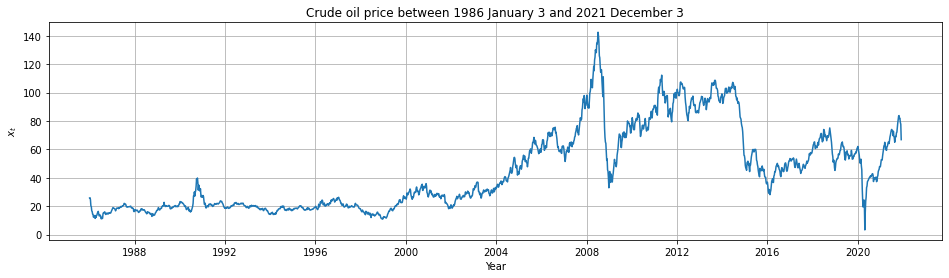

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(ts)
plt.xlabel("Year")
plt.ylabel("$x_t$")
plt.title("Crude oil price between 1986 January 3 and 2021 December 3")
plt.grid(True)

We see that the variance is changing over time. Also large variance/spikes are followed by large variance and small values are followed by small spikes. This supports that GARCH would be a good model for this time series.
   
Additionally, we see that the mean is not constant and adding autoregressive components would be a good idea (taking the different / fitting AR-GARCH model).

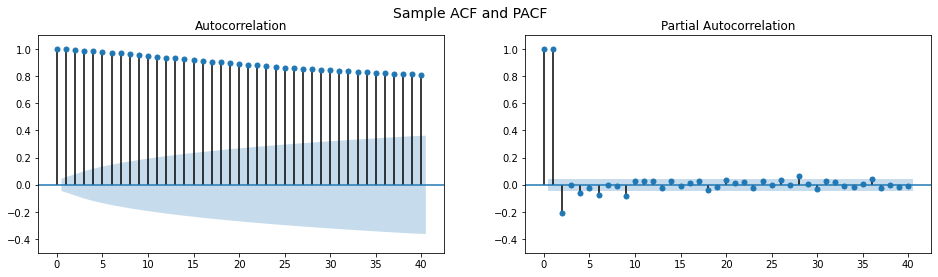

In [ ]:
# ACF and PACF
h_max = 40
fig, axes = plt.subplots(1,2,figsize=(16,4))
fig.suptitle('Sample ACF and PACF',size=14)
plot_acf(ts, lags=h_max, ax=axes[0])
plot_pacf(ts, lags=h_max, method='ywm', ax=axes[1])
axes[0].set_ylim(-0.5,1.1)
axes[1].set_ylim(-0.5,1.1)
plt.show()

ACF and PACF plots supports the fact of the AR component.   
There is no cut-off at ACF.  
From the PACF plot, we that we have a significant spike at lag=1 and the rest correlated values are much smaller, so AR(1) is possible.  

However, we have a somewhat significant value at lag=2, and there are very small values are up until lag=9. Thus AR(2) and AR(9) are worth trying.

We will try to fit AR(9) first to check the ACF and PACF of residuals, and identify potential parameters for GARCH. Then we will check AIC, BIC, and MSE to see if we can get a better fit with a smaller number of parameters, as we saw AR(1) and AR(2) would be good candidates.

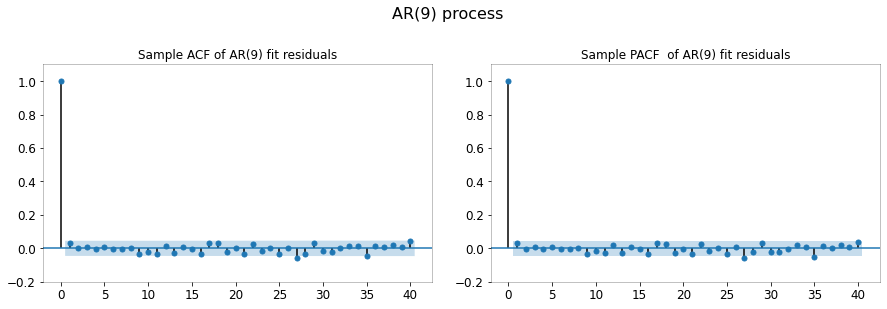

In [ ]:
ar_model = ARIMA(ts, order=(9,0,0))
res = ar_model.fit().resid

h_max = 40
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, figsize=(15,4))
fig.suptitle("AR(9) process",y=1.08,size=16)
plt.subplots_adjust(wspace = 0.15)
plot_acf(res, ax=ax[0], lags=h_max)
plot_pacf(res, ax=ax[1], lags=h_max, method='ywm')
for k in range(2):
    ax[k].tick_params(axis='both', labelsize=12)
    [ax[k].spines[line].set_alpha(.3) for line in ["top","bottom","right","left"]]
ax[0].set_title("Sample ACF of AR(9) fit residuals")
ax[1].set_title("Sample PACF  of AR(9) fit residuals")
ax[0].set_ylim(-0.2,1.1)
ax[1].set_ylim(-0.2,1.1)

plt.show()

We see that the residuals appear uncorrelated. That indicates that AR(9) can be a good fit.

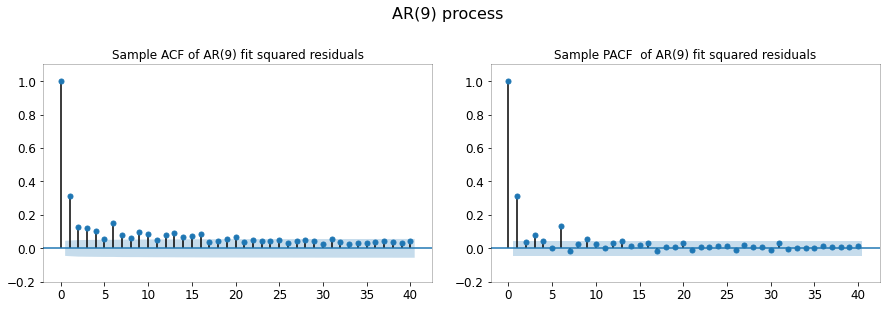

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, figsize=(15,4))
fig.suptitle("AR(9) process",y=1.08,size=16)
plt.subplots_adjust(wspace = 0.15)
plot_acf(res**2, ax=ax[0], lags=h_max)
plot_pacf(res**2, ax=ax[1], lags=h_max, method='ywm')

for k in range(2):
    ax[k].tick_params(axis='both', labelsize=12)
    [ax[k].spines[line].set_alpha(.3) for line in ["top","bottom","right","left"]]

ax[0].set_title("Sample ACF of AR(9) fit squared residuals")
ax[1].set_title("Sample PACF  of AR(9) fit squared residuals")
ax[0].set_ylim(-0.2,1.1)
ax[1].set_ylim(-0.2,1.1)

plt.show()

Even though the residuals are uncorrelated, we see that the squared residuals are not independent. AR model by itself will not be a good fit. We need to fit AR-GARCH model.  

From the PACF plot, we see that significant values is at lag=1 and after it the values are close to zero, except somewhat significant value is at lag=6.

We can say that a potentially good fit would be with p=1 or 6 in GARCH(p,q).

For q parameter we have to try a few options and check which model would be better.

To select the best model we will comapare MSEs on the test set, in addition to checking AIC and BIC.  

In [ ]:
# split into train and test
n = int(ts.shape[0]*0.2)
train = ts.iloc[n:,:]
test = ts.iloc[: n,:]
print('train set size: ', train.shape)
print('test set size: ', test.shape)

train set size:  (1500, 1)
test set size:  (375, 1)


Fist, let's fit AR(9)-GARCH(6,0) based on our observations from the ACF, PACF plots to have some strting point.

In [ ]:
# estimate parameters
model_1 = arch_model(train, mean='AR', lags=9, vol='GARCH', p=6, q=0)
model_fit_gar = model_1.fit()
print(model_fit_gar.summary())

# MSE
model_fit_gar_forecast = model_fit_gar.forecast(horizon=test.shape[0])
forecasted = model_fit_gar_forecast.mean.values[-1, :]
mse1 = mean_squared_error(test, forecasted)
print('MSE of AR(9)-GARCH(6) = ', mse1)

Iteration:      1,   Func. Count:     19,   Neg. LLF: 2824.167988688762
Iteration:      2,   Func. Count:     45,   Neg. LLF: 2823.9693454117887
Iteration:      3,   Func. Count:     69,   Neg. LLF: 2818.119143138958
Iteration:      4,   Func. Count:     91,   Neg. LLF: 2816.531347192641
Iteration:      5,   Func. Count:    113,   Neg. LLF: 2815.2485967585967
Iteration:      6,   Func. Count:    135,   Neg. LLF: 2813.245944040904
Iteration:      7,   Func. Count:    156,   Neg. LLF: 2809.71963394892
Iteration:      8,   Func. Count:    176,   Neg. LLF: 2800.5666091212142
Iteration:      9,   Func. Count:    196,   Neg. LLF: 2769.5453198886057
Iteration:     10,   Func. Count:    217,   Neg. LLF: 2737.4506835235225
Iteration:     11,   Func. Count:    239,   Neg. LLF: 2728.5810852583822
Iteration:     12,   Func. Count:    259,   Neg. LLF: 2693.4077808668644
Iteration:     13,   Func. Count:    280,   Neg. LLF: 2681.1204786342614
Iteration:     14,   Func. Count:    300,   Neg. LLF: 265

From the model's summary, we see that all alpha coefficients are statisticaly significant. However, the p-value for the 2nd one =0.0427, which is close to 0.05.   

For AR part, 4th coeficient through 9th are not statistically significant. We have to eveluate how the model will look without them.

MSE=1,312.55, Log-Likelihood=-2527.81, AIC= 5089.61, and BIC=5179.84

We will explore a few additional options, select the model with minimal MSE and compare other characteristics.

In [ ]:
# calculate MSE score for a different combination of m & p & q in AR(m)-GARCH(p,q)
p = [0,1,2,3,4,5,6]
q = [0,1,2,3,4,5,6]
lags = [1,2,3,4,5,6,8,9]

mse_list = []
params = []
for l in lags:
  for i in p:
      for j in q:
        try:
          model_ = arch_model(train, mean='AR', lags=l, vol='GARCH', p=i, q=j)
          model_fit_ = model_.fit(update_freq=0, disp='off')
          model_fit_forecast = model_fit_.forecast(horizon=test.shape[0])
          xt_forecasted = model_fit_forecast.mean.values[-1, :]
          mse = mean_squared_error(test, xt_forecasted)
          mse_list.append(mse)
          params.append({'lags': l, 'p': i, 'q': j})
        except Exception:
            pass

In [ ]:
# store results in df
results_df = pd.DataFrame(params)
results_df['MSE'] = mse_list
results_df = results_df.sort_values(['MSE'], ascending=True, ignore_index=True)
results_df

,lags,p,q,MSE
0,1,1,0,1025.175065
1,2,4,0,1026.393700
2,2,1,0,1038.066400
3,1,5,0,1067.009649
4,2,5,0,1067.466191
...,...,...,...,...
331,6,3,0,1254.749872
332,3,6,0,1264.816575
333,1,6,0,1284.273317
334,9,6,0,1312.551730


AR(1)-GARCH(1,0) has the min MSE of 1,025.175. This is significantly lower compared to our initial model (MSE=1,312.55).

Additionally, our intial evaluation of ACF and PACF plots of $x_t$ and squared residuals showed that we had a very significant correlation at lag=1, and AR(1)-GARCH(1,0) is potentially a good fit.

Let's fit the model and check other characteristics.

In [ ]:
# fit the final model using parameters that provide the smallest MSE
model_best = arch_model(train, mean='AR', lags=1, vol='GARCH', p=1, q=0)
model_ar_garch_fit = model_best.fit()
print(model_ar_garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 2964.5787780865285
Iteration:      2,   Func. Count:     18,   Neg. LLF: 2963.102806527412
Iteration:      3,   Func. Count:     27,   Neg. LLF: 2955.8129222280677
Iteration:      4,   Func. Count:     35,   Neg. LLF: 2953.493901471771
Iteration:      5,   Func. Count:     42,   Neg. LLF: 2937.3870205874528
Iteration:      6,   Func. Count:     49,   Neg. LLF: 2933.342703410827
Iteration:      7,   Func. Count:     55,   Neg. LLF: 2921.060598556524
Iteration:      8,   Func. Count:     61,   Neg. LLF: 2919.047327135814
Iteration:      9,   Func. Count:     67,   Neg. LLF: 2918.7641525957542
Iteration:     10,   Func. Count:     73,   Neg. LLF: 2918.715300561609
Iteration:     11,   Func. Count:     79,   Neg. LLF: 2918.7111589862457
Iteration:     12,   Func. Count:     85,   Neg. LLF: 2918.7108219558336
Iteration:     13,   Func. Count:     91,   Neg. LLF: 2918.7108209474795
Optimization terminated successfully.    (Exit mode 0)
  

We see that even MSE is significantly smaller compared to the initial model, AIC and BIC are higher.   
However, our criteria for the model is MSE. Also we see that all coefficients are statistically significant, plus it's a much simpler model that provides a smaller MSE.

In [ ]:
# create datetime indexes for 3 months ahead predictions
pred_time = pd.date_range(pd.datetime(2021, 12, 10), periods=13, freq='7D')
pred_time

DatetimeIndex(['2021-12-10', '2021-12-17', '2021-12-24', '2021-12-31',
               '2022-01-07', '2022-01-14', '2022-01-21', '2022-01-28',
               '2022-02-04', '2022-02-11', '2022-02-18', '2022-02-25',
               '2022-03-04'],
              dtype='datetime64[ns]', freq='7D')

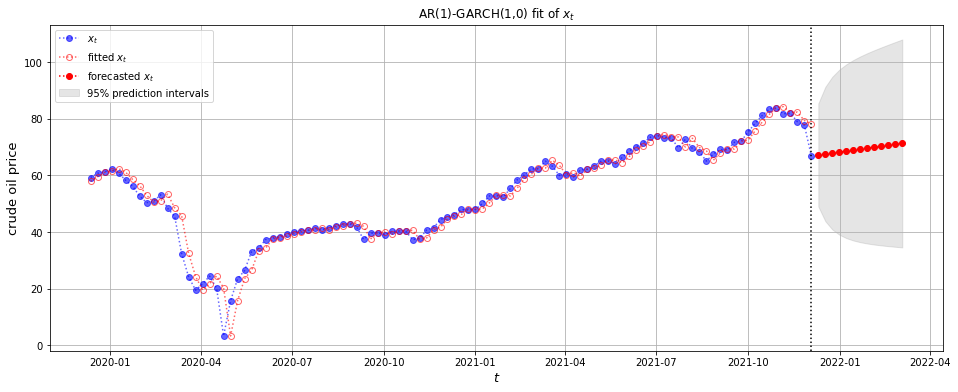

In [ ]:
# fit model to the entire data
ts_order = ts.iloc[::-1]
model_best_garch = arch_model(ts_order , mean='AR', lags=1, vol='GARCH', p=1, q=0)
model_ar_garch_fit_garch = model_best_garch.fit(disp='off')

plt.figure(figsize=(16,6))
fitted_values_ = ts_order.sub(model_ar_garch_fit_garch.resid, axis=0).dropna()
plt.plot(ts_order.index[-104:],ts_order.iloc[-104:],linestyle=':', marker='o',color='blue', alpha=0.6, label = r"$x_t$")
plt.plot(ts_order.index[-104:],fitted_values_[-104:],linestyle=':', marker='o', mfc='none', alpha=0.6, color='red',label = r"fitted $x_t$")
plt.title("AR(1)-GARCH(1,0) fit of $x_t$")

# forecast 3 months (13 weeks) ahead starting from n+1
m=13
model_fit_forecast = model_ar_garch_fit_garch.forecast(horizon=m)
xt_forecasted_ = model_fit_forecast.mean.values[-1, :]
pred_intL = xt_forecasted_ - 1.96*np.sqrt(model_fit_forecast.variance.values[-1, :])
pred_intR = xt_forecasted_ + 1.96*np.sqrt(model_fit_forecast.variance.values[-1, :])

plt.axvline(x=pd.to_datetime('2021-12-03'),linestyle=':',color='k')
plt.plot(pred_time, xt_forecasted_, linestyle=':', marker='o',color='red',label = "forecasted $x_t$")
plt.fill_between(pred_time, pred_intL, pred_intR, color='gray', alpha=.2, label = "95% prediction intervals")
plt.legend(loc = 'upper left')
plt.xlabel('$t$', fontsize=13)
plt.ylabel('crude oil price', fontsize=13)
plt.grid(True)

## 3. NN

In this problem, we consider observations of temperature (in Celsius) measured every 10 minutes in Jena, Germany between January 2009 and January 2017. The dataset is availible at https://www.bgc-jena.mpg.de/wetter/.

We will build several Neural Network (NN) models and compare them.

In [ ]:
df3 = pd.read_csv('jena_climate_2009_2016.csv',parse_dates=True,index_col='Date Time')
xt3 = df3['T (degC)']
xt3 = xt3.reset_index(drop=True)
display(df3.head())
display(df3.tail())
xt3.tail()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2016-12-31 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
2016-12-31 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
2016-12-31 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
2016-12-31 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8
2017-01-01 00:00:00,999.82,-4.82,268.36,-8.42,75.70,4.27,3.23,1.04,2.01,3.23,1296.38,1.23,1.96,184.9


420546   -4.05
420547   -3.35
420548   -3.16
420549   -4.23
420550   -4.82
Name: T (degC), dtype: float64

In [ ]:
type(xt3)

pandas.core.series.Series

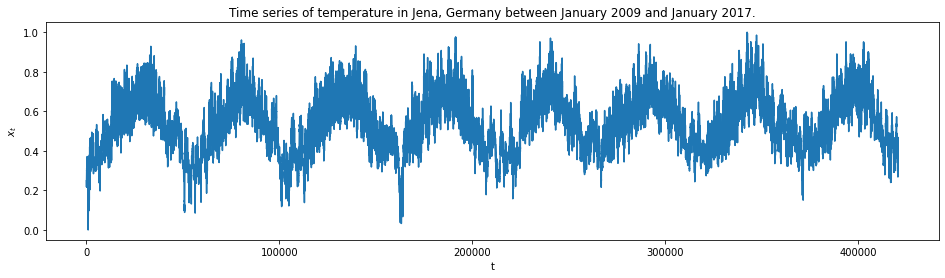

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(xt3)
plt.xlabel("t")
plt.ylabel("$x_t$")
plt.title("Time series of temperature in Jena, Germany between January 2009 and January 2017.")
plt.show()

In [ ]:
#rescale the time series
xt_min = min(xt3)
xt_max = max(xt3)
xt3 = (xt3-xt_min)/(xt_max-xt_min)

In [ ]:
n_timesteps = 144

features_set = []
labels = []
for i in range(n_timesteps, xt3.shape[0]):
    features_set.append(xt3[i-n_timesteps:i])
    labels.append(xt3[i])

features_set, labels = np.array(features_set), np.array(labels)
features_set = np.reshape(features_set,(features_set.shape[0], features_set.shape[1], 1))

In [ ]:
print("features_set.shape is ", features_set.shape)
print("labels.shape is ", labels.shape)

features_set.shape is  (420407, 144, 1)
labels.shape is  (420407,)


In [ ]:
# split into train and test sets
n = features_set.shape[0]
n_train = int(n * 0.70)
n_test = n - n_train

features_set_train, features_set_test =  features_set[0:n_train,:,:], features_set[n_train:n,:,:]
labels_train, labels_test =  labels[0:n_train], labels[n_train:n]

print("features_set_train.shape is ", features_set_train.shape)
print("labels_train.shape is ", labels_train.shape)
print("\nfeatures_set_test.shape is ", features_set_test.shape)
print("labels_test.shape is ", labels_test.shape)

features_set_train.shape is  (294284, 144, 1)
labels_train.shape is  (294284,)

features_set_test.shape is  (126123, 144, 1)
labels_test.shape is  (126123,)


In [ ]:
n_features = 1

model_rnn = models.Sequential()
model_rnn.add(layers.SimpleRNN(32, activation='relu', input_shape=(n_timesteps,n_features)))
model_rnn.add(layers.Dense(1, activation='linear'))

model_rnn.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_3 (SimpleRNN)    (None, 32)                1088      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,121
Trainable params: 1,121
Non-trainable params: 0
_________________________________________________________________


In [ ]:
nepochs = 20
model_rnn.compile(optimizer='adam',
              loss='mse')
history = model_rnn.fit(features_set_train, labels_train,
          epochs=nepochs,
          batch_size=128,
          validation_data=(features_set_test, labels_test))
result_1 = history.history

Epoch 1/20
2300/2300 [==============================] - 89s 38ms/step - loss: 1.3257e-04 - val_loss: 2.2997e-05
Epoch 2/20
2300/2300 [==============================] - 80s 35ms/step - loss: 1.9060e-05 - val_loss: 1.7672e-05
Epoch 3/20
2300/2300 [==============================] - 127s 55ms/step - loss: 1.5843e-05 - val_loss: 1.6786e-05
Epoch 4/20
2300/2300 [==============================] - 130s 56ms/step - loss: 1.3862e-05 - val_loss: 2.4575e-05
Epoch 5/20
2300/2300 [==============================] - 97s 42ms/step - loss: 1.2943e-05 - val_loss: 1.6911e-05
Epoch 6/20
2300/2300 [==============================] - 103s 45ms/step - loss: 1.2702e-05 - val_loss: 1.1512e-05
Epoch 7/20
2300/2300 [==============================] - 82s 36ms/step - loss: 1.2783e-05 - val_loss: 1.2665e-05
Epoch 8/20
2300/2300 [==============================] - 79s 35ms/step - loss: 1.2685e-05 - val_loss: 1.1465e-05
Epoch 9/20
2300/2300 [==============================] - 81s 35ms/step - loss: 1.2520e-05 - val_loss: 

<Figure size 432x288 with 0 Axes>

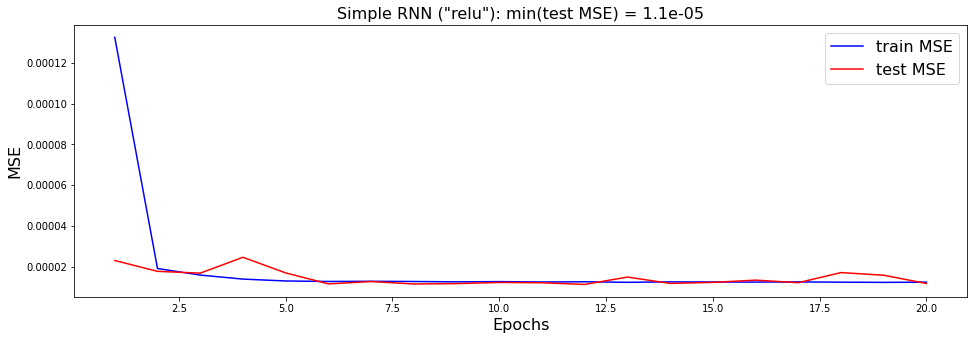

In [ ]:
plt.clf()   # clear figure
train_mse = result_1['loss']
test_mse = result_1['val_loss']

plt.figure(figsize=(16,5))
plt.plot(range(1,nepochs+1), train_mse, 'b', label='train MSE',color="blue")
plt.plot(range(1,nepochs+1), test_mse, 'b', label='test MSE',color="red")

plt.title('Simple RNN ("relu"): min(test MSE) = ' + str(round(min(test_mse),6)),fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('MSE',fontsize=16)
plt.legend(loc = 'upper right',fontsize=16)
#plt.ylim(0,0.001)

plt.show()

We got a low MSE score on the testing set. We will try to increase the number batch size to improve performance, and also we will try the "tanh" activation fanction.

In [ ]:
n_features = 1

model_rnn2 = models.Sequential()
model_rnn2.add(layers.SimpleRNN(32, activation='tanh', input_shape=(n_timesteps,n_features)))
model_rnn2.add(layers.Dense(1, activation='linear'))

model_rnn2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 32)                1088      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,121
Trainable params: 1,121
Non-trainable params: 0
_________________________________________________________________


In [ ]:
nepochs = 20
model_rnn2.compile(optimizer='adam',
              loss='mse')
history = model_rnn2.fit(features_set_train, labels_train,
          epochs=nepochs,
          batch_size=256,
          validation_data=(features_set_test, labels_test))
result_2 = history.history

Epoch 1/20
1150/1150 [==============================] - 53s 45ms/step - loss: 0.0108 - val_loss: 0.0012
Epoch 2/20
1150/1150 [==============================] - 70s 61ms/step - loss: 0.0011 - val_loss: 8.9041e-04
Epoch 3/20
1150/1150 [==============================] - 55s 47ms/step - loss: 8.4133e-04 - val_loss: 7.3502e-04
Epoch 4/20
1150/1150 [==============================] - 49s 43ms/step - loss: 7.1201e-04 - val_loss: 6.4952e-04
Epoch 5/20
1150/1150 [==============================] - 48s 42ms/step - loss: 6.4036e-04 - val_loss: 5.8430e-04
Epoch 6/20
1150/1150 [==============================] - 49s 43ms/step - loss: 6.6552e-04 - val_loss: 5.9119e-04
Epoch 7/20
1150/1150 [==============================] - 49s 43ms/step - loss: 6.1769e-04 - val_loss: 5.8820e-04
Epoch 8/20
1150/1150 [==============================] - 49s 42ms/step - loss: 6.0996e-04 - val_loss: 5.7780e-04
Epoch 9/20
1150/1150 [==============================] - 49s 43ms/step - loss: 6.0743e-04 - val_loss: 5.7288e-04
Epoc

<Figure size 432x288 with 0 Axes>

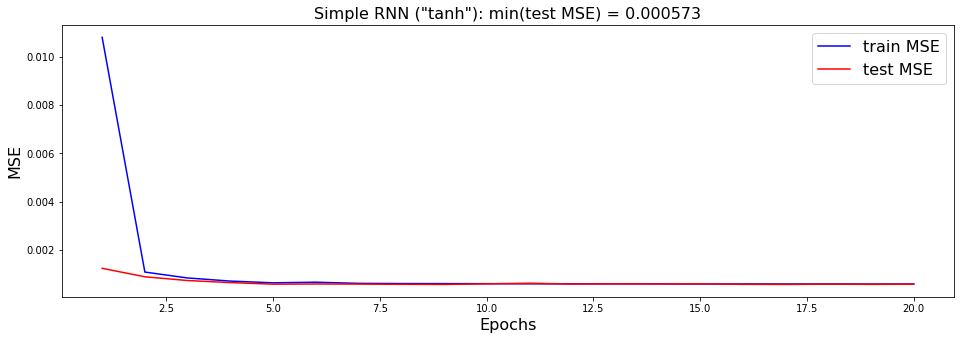

In [ ]:
plt.clf()   # clear figure
train_mse = result_2['loss']
test_mse = result_2['val_loss']

plt.figure(figsize=(16,5))
plt.plot(range(1,nepochs+1), train_mse, 'b', label='train MSE',color="blue")
plt.plot(range(1,nepochs+1), test_mse, 'b', label='test MSE',color="red")

plt.title('Simple RNN ("tanh"): min(test MSE) = ' + str(round(min(test_mse),6)),fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('MSE',fontsize=16)
plt.legend(loc = 'upper right',fontsize=16)
#plt.ylim(0,0.001)

plt.show()

By switching from "relu" to "tanh" activation function and keeping the same archetecture with ahigher batch size, we got got a small MSE value, but it's higher than with "relu".  
On the other hand, training this model was much faster.

As we saw on the first RNN model the test, MSE was slightly increasing over the epochs. We can try to get the same lower MSE by adding regularization and early stopping to stop training when MSE starts increasing.

In [ ]:
n_features = 1

model_rnn_es = models.Sequential()
model_rnn_es.add(layers.SimpleRNN(32, activation='relu',\
                    kernel_regularizer=l2(0.01), recurrent_regularizer=l2(0.01),\
                    input_shape=(n_timesteps,n_features)))

model_rnn_es.add(Dropout(0.2))
model_rnn_es.add(layers.Dense(1, activation='linear'))

model_rnn_es.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_4 (SimpleRNN)    (None, 32)                1088      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,121
Trainable params: 1,121
Non-trainable params: 0
_________________________________________________________________


In [ ]:
nepochs = 20
model_rnn_es.compile(optimizer='adam',
              loss='mse')
history_es = model_rnn_es.fit(features_set_train, labels_train,
          epochs=nepochs,
          batch_size=256,
          validation_data=(features_set_test, labels_test),
          callbacks=[EarlyStopping(monitor='val_loss', patience = 1)])

result_es = history_es.history

Epoch 1/20
1150/1150 [==============================] - 52s 44ms/step - loss: 0.0477 - val_loss: 0.0028
Epoch 2/20
1150/1150 [==============================] - 54s 47ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 3/20
1150/1150 [==============================] - 50s 43ms/step - loss: 0.0018 - val_loss: 8.3687e-04
Epoch 4/20
1150/1150 [==============================] - 52s 45ms/step - loss: 0.0016 - val_loss: 7.2985e-04
Epoch 5/20
1150/1150 [==============================] - 51s 45ms/step - loss: 0.0014 - val_loss: 6.5007e-04
Epoch 6/20
1150/1150 [==============================] - 50s 43ms/step - loss: 0.0013 - val_loss: 5.4906e-04
Epoch 7/20
1150/1150 [==============================] - 50s 43ms/step - loss: 0.0011 - val_loss: 4.5423e-04
Epoch 8/20
1150/1150 [==============================] - 49s 43ms/step - loss: 0.0010 - val_loss: 3.7734e-04
Epoch 9/20
1150/1150 [==============================] - 68s 59ms/step - loss: 9.7130e-04 - val_loss: 3.5193e-04
Epoch 10/20
1150/1150 [=========

<Figure size 432x288 with 0 Axes>

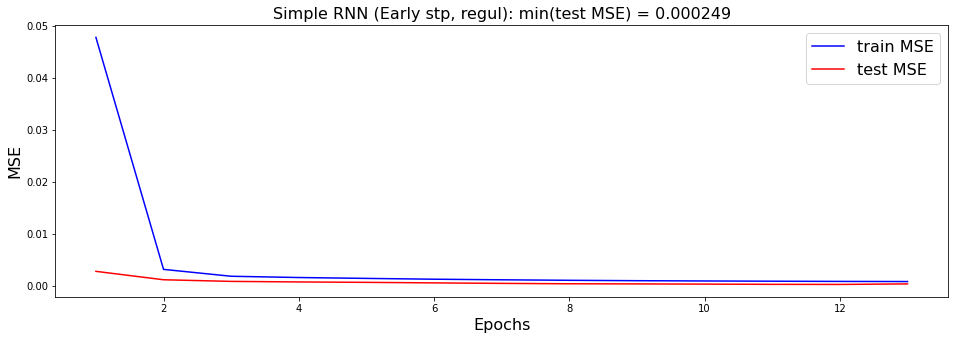

In [ ]:
plt.clf()   # clear figure
train_mse_es = result_es['loss']
test_mse_es = result_es['val_loss']

plt.figure(figsize=(16,5))
plt.plot(range(1,len(train_mse_es)+1), train_mse_es, 'b', label='train MSE',color="blue")
plt.plot(range(1,len(test_mse_es)+1), test_mse_es, 'b', label='test MSE',color="red")

plt.title('Simple RNN (Early stp, regul): min(test MSE) = ' + str(round(min(test_mse_es),6)),fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('MSE',fontsize=16)
plt.legend(loc = 'upper right',fontsize=16)
#plt.ylim(0,0.001)

plt.show()

We see that model stopped at epoch 13 as the MSE would start increasing. By adding dropout and regularization that suppose to help with overfitting, we actually see a slight underfit now. Most likely we need to adjust values for L2 or use either Dropout rate or regularization but maybe not both.

Now will fit LSTM model with the same structure for comparison, plus a Dropout layer with a 20% rate to account for overfitting.

In [ ]:
n_features = 1

model_lstm = models.Sequential()
model_lstm.add(LSTM(32, return_sequences=False, activation='tanh', input_shape=(n_timesteps,n_features)))
model_lstm.add(Dropout(0.2))
model_lstm.add(layers.Dense(1, activation='linear'))

model_lstm.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 32)                4352      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4,385
Trainable params: 4,385
Non-trainable params: 0
_________________________________________________________________


In [ ]:
nepochs = 20
model_lstm.compile(optimizer='adam',
              loss='mse')
history3 = model_lstm.fit(features_set_train, labels_train,
          epochs=nepochs,
          batch_size=256,
          validation_data=(features_set_test, labels_test))
history_lstm = history3.history

Epoch 1/20
1150/1150 [==============================] - 220s 190ms/step - loss: 0.0060 - val_loss: 1.1860e-04
Epoch 2/20
1150/1150 [==============================] - 273s 237ms/step - loss: 0.0015 - val_loss: 9.0591e-05
Epoch 3/20
1150/1150 [==============================] - 358s 311ms/step - loss: 7.8806e-04 - val_loss: 9.5093e-05
Epoch 4/20
1150/1150 [==============================] - 369s 321ms/step - loss: 3.8863e-04 - val_loss: 6.6870e-05
Epoch 5/20
1150/1150 [==============================] - 322s 280ms/step - loss: 2.6204e-04 - val_loss: 5.6168e-05
Epoch 6/20
1150/1150 [==============================] - 205s 179ms/step - loss: 2.3318e-04 - val_loss: 4.6448e-05
Epoch 7/20
1150/1150 [==============================] - 193s 168ms/step - loss: 2.1867e-04 - val_loss: 3.8993e-05
Epoch 8/20
1150/1150 [==============================] - 175s 152ms/step - loss: 2.0603e-04 - val_loss: 2.9319e-05
Epoch 9/20
1150/1150 [==============================] - 248s 216ms/step - loss: 1.9838e-04 - val

<Figure size 432x288 with 0 Axes>

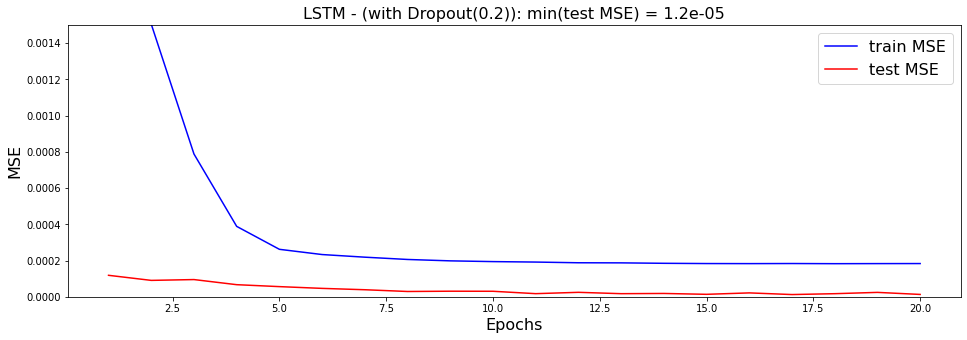

In [ ]:
plt.clf()   # clear figure
train_mse = history_lstm['loss']
test_mse = history_lstm['val_loss']

plt.figure(figsize=(16,5))
plt.plot(range(1,nepochs+1), train_mse, 'b', label='train MSE',color="blue")
plt.plot(range(1,nepochs+1), test_mse, 'b', label='test MSE',color="red")

#plt.ylim((0, 0.0001))
plt.title('LSTM - (with Dropout(0.2)): min(test MSE) = ' + str(round(min(test_mse),6)),fontsize=16)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('MSE',fontsize=16)
plt.legend(loc = 'upper right',fontsize=16)
plt.ylim(0,0.0015)

plt.show()

we eneded up under-fitting here.

For prediction we will use the Simple RNN model without Dropout layers and regularization.   
Even though it's not the optimized model, it has relatively low test MSE and highest performance.

In [ ]:
xhat = model_rnn2.predict(features_set)

In [ ]:
m=144
data_= pd.date_range(len(xt3), len(xt3)+m)
def predict(m, model):
    prediction_list = data_[-m:]

    for _ in range(m):
        x = prediction_list[-m:]
        x = x.reshape((1, m, 1))
        out = model.predict(x)[0][0]
        prediction_list = np.append(prediction_list, out)
    prediction_list = prediction_list[m:]
    return prediction_list

forecast = predict(m, model_rnn2)

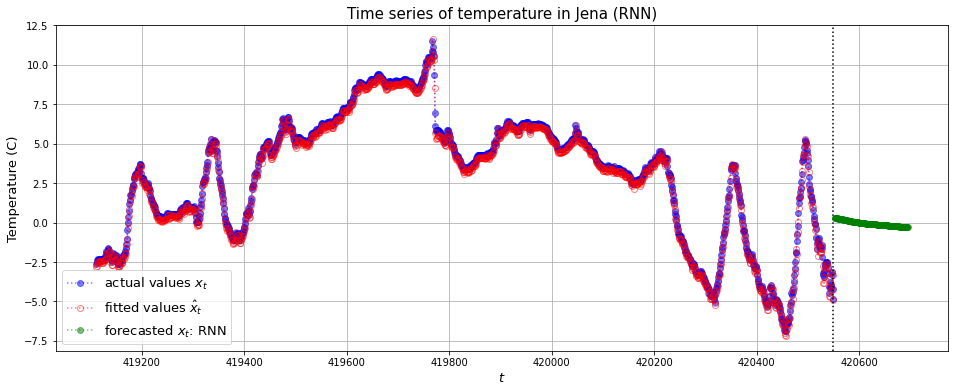

In [ ]:
# xt_fitted_rnn = model_rnn2.predict(features_set.iloc[:,0:1])
window = np.arange(len(xt3)-1440,len(xt3))

plt.figure(figsize=(16,6))
plt.title("Time series of temperature in Jena (RNN)", fontsize=15)

n = len(xt3)
m = 144
xt4 = xt_min + xt3*(xt_max-xt_min)
xt_fitted4 = xt_min + xhat*(xt_max-xt_min)
xt_forecasted_rnn = xt_min + forecast*(xt_max-xt_min)

plt.plot(window,xt4[window], linestyle=':', marker='o',color='blue', alpha=0.5, label = "actual values $x_t$")
plt.plot(window,xt_fitted4[window-n_timesteps], linestyle=':', marker='o', mfc='none', alpha=0.5, \
         color='red',label = "fitted values $\hat{x}_t$")
plt.axvline(x=len(xt4)-1,linestyle=':',color='k')

plt.plot(range(n+1,n+m+1), forecast, linestyle=':', marker='o',color='green', alpha=0.5, label = "forecasted $x_t$: RNN")
plt.ylabel('Temperature (C)', fontsize=13)
plt.xlabel('$t$', fontsize=13)
plt.grid(True)
plt.legend(loc = 'lower left',fontsize=13)
plt.show()
